In [1]:
import pandas as pd 
df = pd.read_csv("data/accepted_2007_to_2018Q4.csv")

# target 생성
status_map = { 
    "Fully Paid" : 0 ,
    "Charged Off" :1, 
    "Default" : 1
}

df["target"] = df["loan_status"].map(status_map)
current_pay = df[df["target"].isnull()].copy() # 현재 상환중인
df = df[df["target"].notnull()].copy()

C:\Users\didwn\AppData\Local\Temp\ipykernel_14544\1395847655.py:2: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/accepted_2007_to_2018Q4.csv")
C:\Users\didwn\AppData\Local\Temp\ipykernel_14544\1395847655.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target"] = df["loan_status"].map(status_map)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print("=" * 60)
print("로드 완료")
print("=" * 60)

로드 완료


issue_year
2012     25626
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
2018     56318
Name: count, dtype: int64


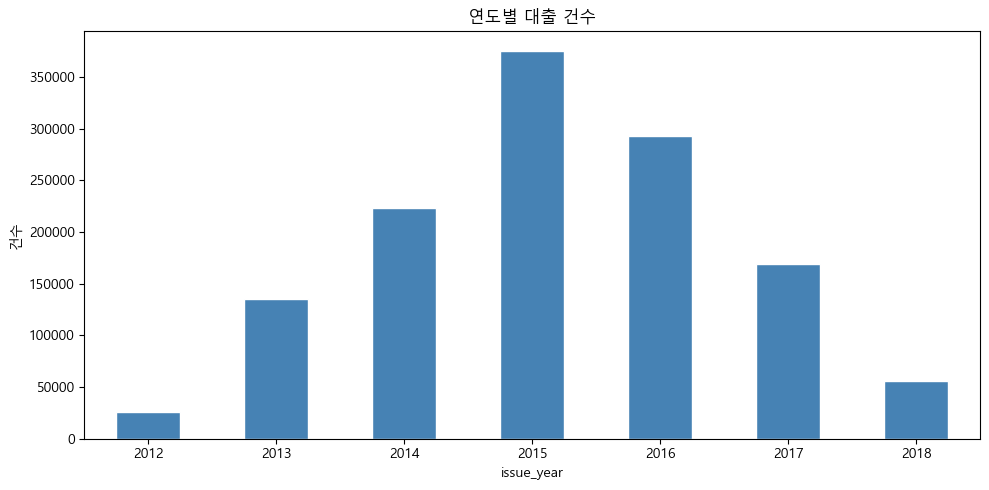

In [7]:
# 변경 정책 반영 
# 연도 자르기 
change_mask = "num_actv_bc_tl"
df = df.dropna(subset=[change_mask])

#날짜형 변수 변환 
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['issue_year'] = df['issue_d'].dt.year

print(df['issue_year'].value_counts().sort_index())

df['issue_year'].value_counts().sort_index().plot(
    kind='bar', figsize=(10, 5), color='steelblue', edgecolor='white'
)
plt.title('연도별 대출 건수')
plt.ylabel('건수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
"""
제거 대상 컬럼
"""

drop_columns = [
    # ── 그룹 1: 사후 상환 실적 ──
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d',

    # ── 그룹 2: 잔액 사후 정보 ──
    'out_prncp', 'out_prncp_inv',

    # ── 그룹 3: 상각/추심 사후 ──
    'recoveries', 'collection_recovery_fee',

    # ── 그룹 4: 사후 신용 스냅샷 ──
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',

    # ── 그룹 5: Hardship / Settlement ──
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'orig_projected_additional_accrued_interest',
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term',

    # ── 그룹 6: 특별 상환 계획 ──
    'pymnt_plan', 'payment_plan_start_date',

    # ── 그룹 7: 승인/집행 결과 ──
    'funded_amnt', 'funded_amnt_inv', 'disbursement_method',

    # ── 그룹 8: 식별자 및 상수 ──
    'id', 'member_id', 'url', 'title', 'zip_code', 'policy_code',

    # ── 그룹 9: 원본 타겟 변수 ──
    'loan_status',

    # ── 그룹 10: 효과 크기 낮은 변수 ── 후보 
    #'initial_list_status', 'total_acc', 'open_acc',
    #'application_type', 'addr_state', 'earliest_cr_line', 'pub_rec',

    # ── 그룹 11: 공동 신청(Joint) 관련 ──
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc',
    'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il',
    'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog',

    # 2016년 이후 신규 추가된 세부 신용 리포트 항목 (13개) 
    "open_acc_6m", "open_act_il", "open_il_12m", "open_il_24m","total_bal_il"
    ,"il_util","open_rv_12m","open_rv_24m","max_bal_bc","all_util","inq_fi" 
    ,"total_cu_tl", "inq_last_12m",

    # 3차 검토 사용 불가 판정 
    "desc", "emp_title", 

]

# 중복 검증
assert len(drop_columns) == len(set(drop_columns)), \
    f"중복 존재: {[c for c in drop_columns if drop_columns.count(c) > 1]}"

print(f"총 제거 대상: {len(drop_columns)}개")

# 실제 적용
df = df.drop(columns=[c for c in drop_columns if c in df.columns])

총 제거 대상: 79개


In [9]:
# 전체 컬럼의 null 여부 
null_info = pd.DataFrame({
    '결측수': df.isnull().sum(),
    '결측률': df.isnull().mean().apply(lambda x: f"{x:.2%}")
})
print(null_info[null_info['결측수'] > 0])

                                    결측수     결측률
emp_length                        76489   5.99%
dti                                 374   0.03%
inq_last_6mths                        1   0.00%
mths_since_last_delinq           634730  49.67%
mths_since_last_record          1052888  82.40%
revol_util                          776   0.06%
mths_since_last_major_derog      924066  72.32%
mths_since_rcnt_il               754404  59.04%
avg_cur_bal                          22   0.00%
bc_open_to_buy                    13593   1.06%
bc_util                           14349   1.12%
mo_sin_old_il_acct                38049   2.98%
mo_sin_old_rev_tl_op                  1   0.00%
mo_sin_rcnt_rev_tl_op                 1   0.00%
mths_since_recent_bc              12703   0.99%
mths_since_recent_bc_dlq         958794  75.03%
mths_since_recent_inq            124131   9.71%
mths_since_recent_revol_delinq   832949  65.19%
num_rev_accts                         1   0.00%
num_tl_120dpd_2m                  49876 

In [ ]:
"""
통합전처리
"""
# 1- 대출 기본 정보 
# 2- 차입자 인적 정보 (Borrower Profile)
# emp_title 삭제 
df["emp_length"] = df["emp_length"].fillna("unknown") # 근속 연수 결측치는  unknown 처리
df["home_ownership"] = df["home_ownership"].replace(["ANY","NONE"],"OTHER" ) # 주거 형태  OTHER 로 통합 


# 3- 차입자 부채 부담 (Debt Burden)
# 4- 신용 점수 (FICO Score)
# 5- 연체·부정 이력 (Delinquency & Negative Records)

# 6- 리볼빙 신용 (Revolving Credit)

# 7- 계좌 수량 지표 (Account Counts)
# 8- 잔액 및 한도 지표 (Balance & Limit) 
# 9- 계좌 경과 기간 (Account Age)
# 10- 상세 연체 지표 (Detailed Delinquency) 


In [ ]:
# test 데이터 분할 하고 처리해야 하는 데이터 

In [ ]:
# 결측값 자체가 의미가 있는 컬럼 


In [ ]:
# 다중 공선성이 의심되는 컬럼들

# 6 
Revolving= [
    "revol_bal","revol_util", "total_rev_hi_lim"

]

Bc_card = [
    "bc_open_to_buy", "bc_util", "percent_bc_gt_75", "total_bc_limit","num_actv_bc_tl",
    "num_actv_rev_tl","num_bc_sats"
]